# Case 3: CDC Health Data Exploratory Analysis

This notebook contains exploratory data analysis (EDA) and visualizations for the CDC health sample data.

## Step 1: Import Libraries and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the CDC data
df = pd.read_excel('cdc_1000_sample.xlsx')

# Display basic info about the dataset
print("Dataset Shape:", df.shape)
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset Shape: (1000, 9)

Number of rows: 1000
Number of columns: 9


In [3]:
# Display the first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,gender,height_in,weight_lb,exerany,smoke100,hlthplan,genhlth,bmi
0,56,M,71.5,197.3,0,1,1,excellent,27.13
1,69,M,63.3,157.7,0,1,1,fair,27.67
2,46,M,70.6,211.7,1,1,1,excellent,29.86
3,32,F,64.5,167.4,0,0,1,good,28.29
4,60,F,63.2,105.3,0,0,1,fair,18.53


In [4]:
# Check column names and data types
print("Column Information:")
df.info()

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1000 non-null   int64  
 1   gender     1000 non-null   object 
 2   height_in  1000 non-null   float64
 3   weight_lb  1000 non-null   float64
 4   exerany    1000 non-null   int64  
 5   smoke100   1000 non-null   int64  
 6   hlthplan   1000 non-null   int64  
 7   genhlth    1000 non-null   object 
 8   bmi        1000 non-null   float64
dtypes: float64(3), int64(4), object(2)
memory usage: 70.4+ KB


In [5]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
age          0
gender       0
height_in    0
weight_lb    0
exerany      0
smoke100     0
hlthplan     0
genhlth      0
bmi          0
dtype: int64

Total missing values: 0


In [6]:
# Descriptive statistics for numeric columns
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,age,height_in,weight_lb,exerany,smoke100,hlthplan,bmi
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,49.857000,66.233500,170.40120,0.633000,0.388000,0.853000,27.20712
std,18.114267,4.142916,33.58014,0.482228,0.487538,0.354283,4.16444
min,18.000000,58.000000,100.00000,0.000000,0.000000,0.000000,15.72000
25%,35.000000,63.500000,147.40000,0.000000,0.000000,1.000000,24.29250
50%,50.000000,66.300000,167.55000,1.000000,0.000000,1.000000,27.26000
75%,66.000000,69.100000,192.62500,1.000000,1.000000,1.000000,30.08250
max,79.000000,78.000000,288.90000,1.000000,1.000000,1.000000,39.82000


In [7]:
# Value counts for categorical columns
print("Gender Distribution:")
print(df['gender'].value_counts())
print("\nGeneral Health Distribution:")
print(df['genhlth'].value_counts())
print("\nExercise Status (0=No, 1=Yes):")
print(df['exerany'].value_counts())
print("\nSmoking Status (0=No, 1=Yes):")
print(df['smoke100'].value_counts())

Gender Distribution:
gender
F    559
M    441
Name: count, dtype: int64

General Health Distribution:
genhlth
good         317
very good    309
excellent    177
fair         139
poor          58
Name: count, dtype: int64

Exercise Status (0=No, 1=Yes):
exerany
1    633
0    367
Name: count, dtype: int64

Smoking Status (0=No, 1=Yes):
smoke100
0    612
1    388
Name: count, dtype: int64


---

## Step 2: Data Visualizations

### Chart 1: Age Distribution
**Type:** Histogram  
**Purpose:** Shows the age spread of the sample population.

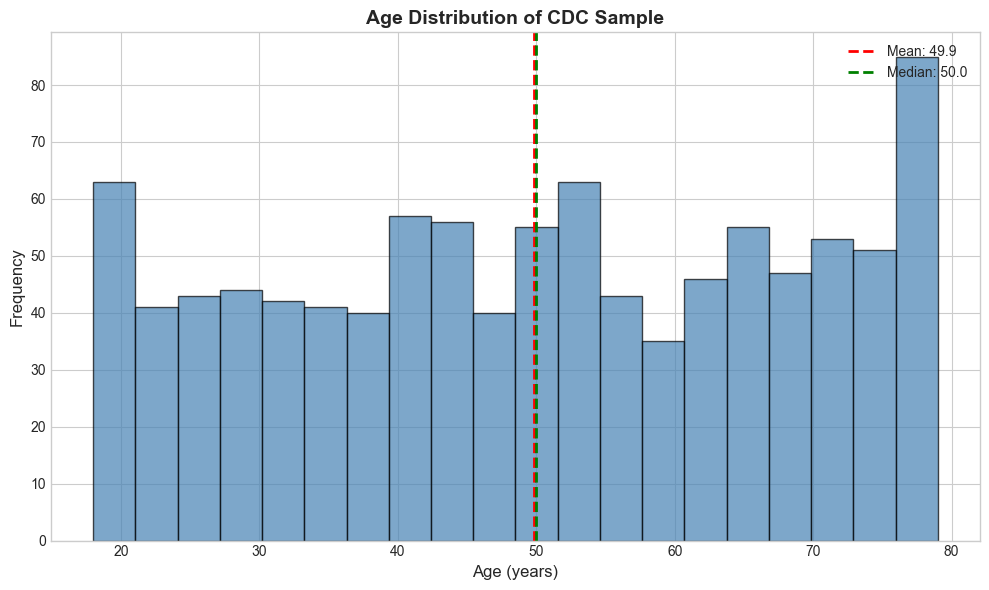


Age Statistics:
  Mean: 49.86 years
  Median: 50.00 years
  Std Dev: 18.11 years
  Min: 18 years
  Max: 79 years


In [8]:
# Chart 1: Age Distribution Histogram
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
ax.hist(df['age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)

# Add mean and median lines
mean_age = df['age'].mean()
median_age = df['age'].median()
ax.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
ax.axvline(median_age, color='green', linestyle='--', linewidth=2, label=f'Median: {median_age:.1f}')

# Labels and title
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Age Distribution of CDC Sample', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nAge Statistics:")
print(f"  Mean: {mean_age:.2f} years")
print(f"  Median: {median_age:.2f} years")
print(f"  Std Dev: {df['age'].std():.2f} years")
print(f"  Min: {df['age'].min()} years")
print(f"  Max: {df['age'].max()} years")

### Chart 2: BMI Distribution
**Type:** Histogram  
**Purpose:** Shows whether the sample skews underweight/normal/overweight/obese.

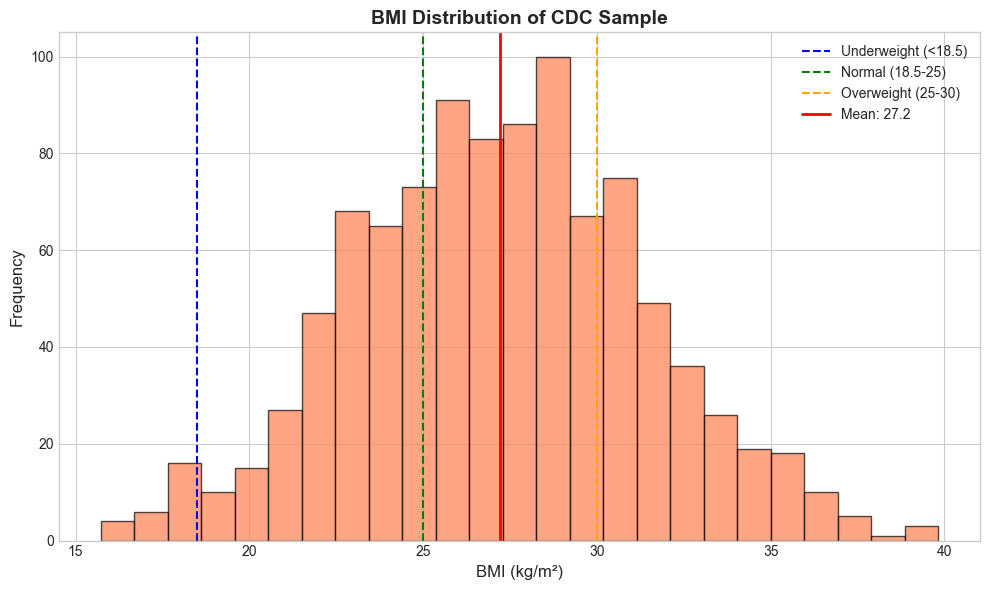


BMI Category Distribution:
bmi_category
Overweight     438
Normal         282
Obese          256
Underweight     24
Name: count, dtype: int64

BMI Statistics:
  Mean: 27.21
  Median: 27.26
  Std Dev: 4.16


In [9]:
# Chart 2: BMI Distribution Histogram
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
ax.hist(df['bmi'], bins=25, color='coral', edgecolor='black', alpha=0.7)

# Add BMI category reference lines
ax.axvline(18.5, color='blue', linestyle='--', linewidth=1.5, label='Underweight (<18.5)')
ax.axvline(25, color='green', linestyle='--', linewidth=1.5, label='Normal (18.5-25)')
ax.axvline(30, color='orange', linestyle='--', linewidth=1.5, label='Overweight (25-30)')

# Add mean line
mean_bmi = df['bmi'].mean()
ax.axvline(mean_bmi, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_bmi:.1f}')

# Labels and title
ax.set_xlabel('BMI (kg/m²)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('BMI Distribution of CDC Sample', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# BMI Category breakdown
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(categorize_bmi)
print("\nBMI Category Distribution:")
print(df['bmi_category'].value_counts())
print(f"\nBMI Statistics:")
print(f"  Mean: {mean_bmi:.2f}")
print(f"  Median: {df['bmi'].median():.2f}")
print(f"  Std Dev: {df['bmi'].std():.2f}")

### Chart 3: Height vs. Weight Scatterplot
**Type:** Scatterplot  
**Purpose:** Visualize the height/weight relationship and BMI pattern.

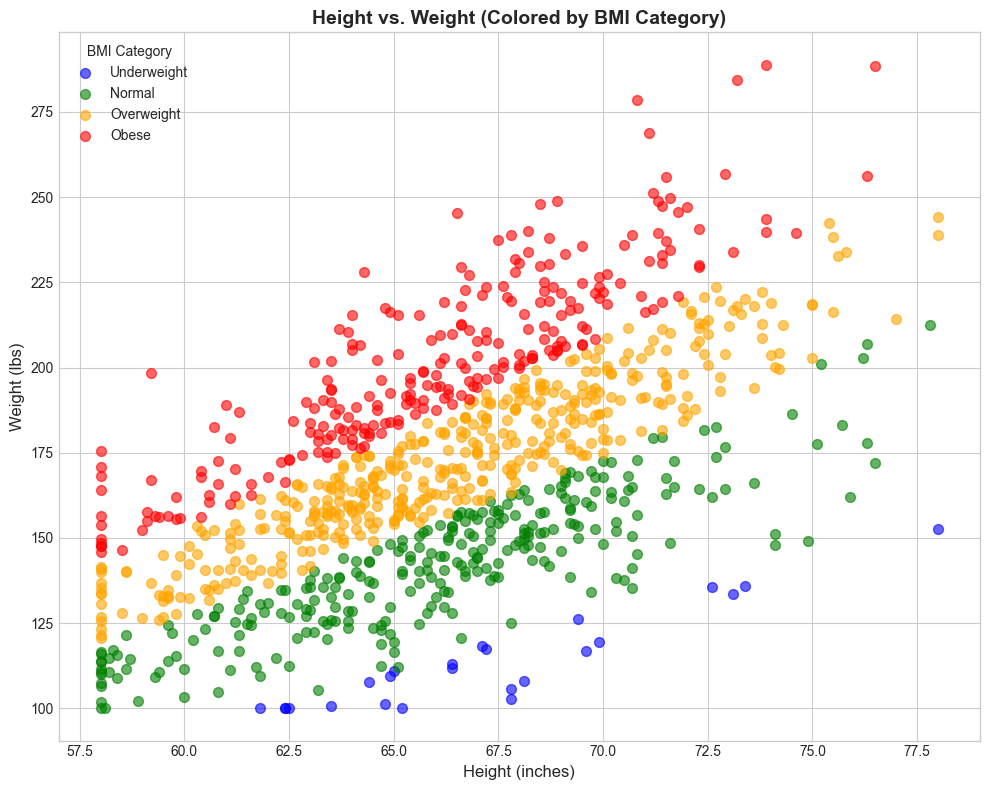


Correlation between Height and Weight: 0.619


In [10]:
# Chart 3: Height vs. Weight Scatterplot
fig, ax = plt.subplots(figsize=(10, 8))

# Create scatterplot colored by BMI category
colors = {'Underweight': 'blue', 'Normal': 'green', 'Overweight': 'orange', 'Obese': 'red'}
for category in ['Underweight', 'Normal', 'Overweight', 'Obese']:
    subset = df[df['bmi_category'] == category]
    ax.scatter(subset['height_in'], subset['weight_lb'], 
               c=colors[category], label=category, alpha=0.6, s=50)

# Labels and title
ax.set_xlabel('Height (inches)', fontsize=12)
ax.set_ylabel('Weight (lbs)', fontsize=12)
ax.set_title('Height vs. Weight (Colored by BMI Category)', fontsize=14, fontweight='bold')
ax.legend(title='BMI Category', loc='upper left')

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['height_in'].corr(df['weight_lb'])
print(f"\nCorrelation between Height and Weight: {correlation:.3f}")

### Chart 4: Exercise Status by Gender
**Type:** Bar Chart (Grouped)  
**Purpose:** Compare physical activity patterns by gender.

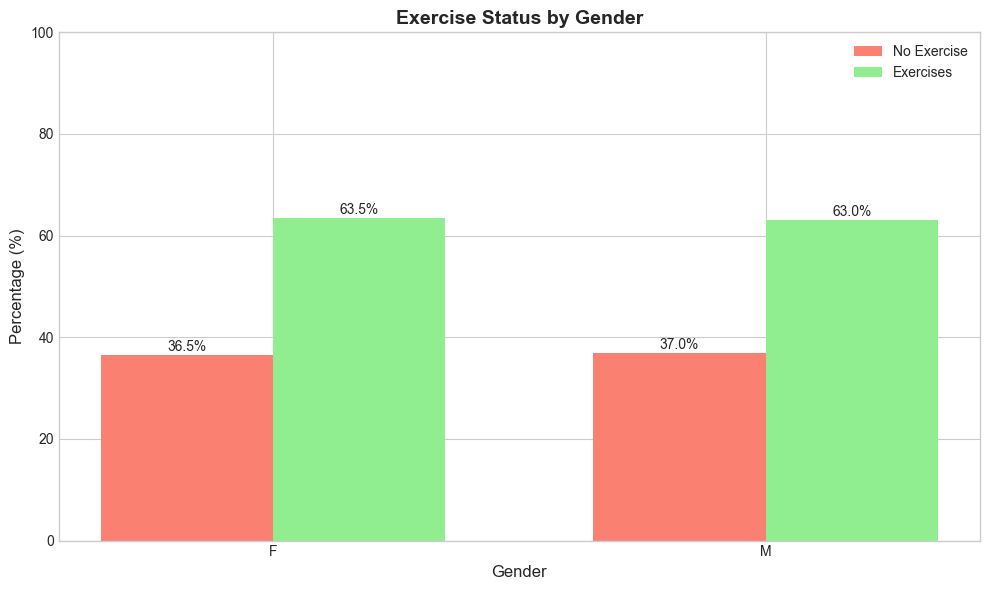


Exercise Status by Gender (%):
        No Exercise  Exercises
gender                        
F              36.5       63.5
M              37.0       63.0


In [11]:
# Chart 4: Exercise Status by Gender (Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

# Create crosstab
exercise_gender = pd.crosstab(df['gender'], df['exerany'], normalize='index') * 100
exercise_gender.columns = ['No Exercise', 'Exercises']

# Plot grouped bar chart
x = np.arange(len(exercise_gender.index))
width = 0.35

bars1 = ax.bar(x - width/2, exercise_gender['No Exercise'], width, label='No Exercise', color='salmon')
bars2 = ax.bar(x + width/2, exercise_gender['Exercises'], width, label='Exercises', color='lightgreen')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

# Labels and title
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Exercise Status by Gender', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(exercise_gender.index)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print the data
print("\nExercise Status by Gender (%):")
print(exercise_gender.round(1))

### Chart 5: Smoking Status by Gender
**Type:** Bar Chart  
**Purpose:** Show smoking percentage differences between males and females.

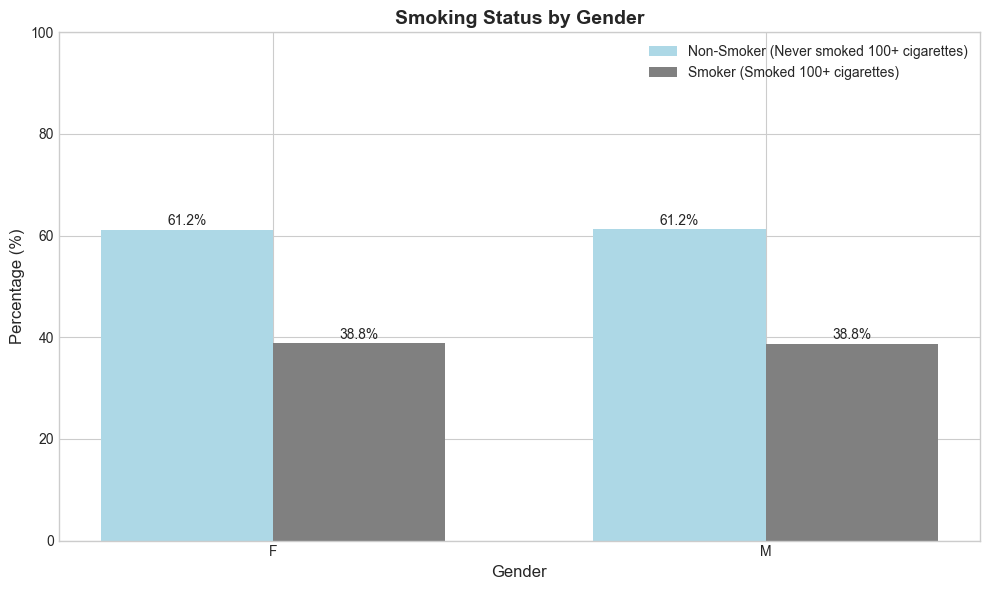


Smoking Status by Gender (%):
        Non-Smoker  Smoker
gender                    
F             61.2    38.8
M             61.2    38.8


In [12]:
# Chart 5: Smoking Status by Gender (Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

# Create crosstab
smoke_gender = pd.crosstab(df['gender'], df['smoke100'], normalize='index') * 100
smoke_gender.columns = ['Non-Smoker', 'Smoker']

# Plot grouped bar chart
x = np.arange(len(smoke_gender.index))
width = 0.35

bars1 = ax.bar(x - width/2, smoke_gender['Non-Smoker'], width, label='Non-Smoker (Never smoked 100+ cigarettes)', color='lightblue')
bars2 = ax.bar(x + width/2, smoke_gender['Smoker'], width, label='Smoker (Smoked 100+ cigarettes)', color='gray')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

# Labels and title
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Smoking Status by Gender', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(smoke_gender.index)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print the data
print("\nSmoking Status by Gender (%):")
print(smoke_gender.round(1))

### Chart 6: General Health Category Distribution
**Type:** Bar Chart  
**Purpose:** Show overall perceived health in the sample.

/var/folders/72/97y_q4kn2cng3wk1b79_ql8w0000gn/T/ipykernel_39554/1956845540.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([cat.title() for cat in health_order], rotation=0)


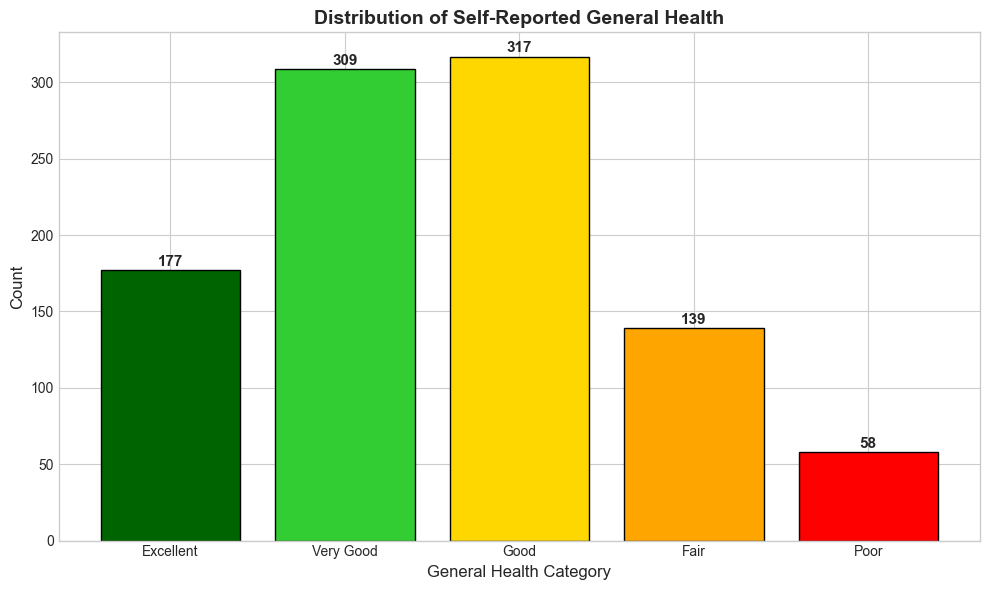


General Health Distribution (%):
  Excellent: 17.7%
  Very Good: 30.9%
  Good: 31.7%
  Fair: 13.9%
  Poor: 5.8%


In [13]:
# Chart 6: General Health Category Distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Order the health categories logically
health_order = ['excellent', 'very good', 'good', 'fair', 'poor']
health_counts = df['genhlth'].value_counts().reindex(health_order)

# Define colors from best to worst health
colors = ['darkgreen', 'limegreen', 'gold', 'orange', 'red']

# Create bar chart
bars = ax.bar(health_counts.index, health_counts.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

# Labels and title
ax.set_xlabel('General Health Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Self-Reported General Health', fontsize=14, fontweight='bold')
ax.set_xticklabels([cat.title() for cat in health_order], rotation=0)

plt.tight_layout()
plt.show()

# Print percentages
print("\nGeneral Health Distribution (%):")
health_pct = (health_counts / len(df) * 100).round(1)
for cat, pct in health_pct.items():
    print(f"  {cat.title()}: {pct}%")

### Chart 7: BMI vs. General Health
**Type:** Boxplot  
**Purpose:** Compare whether better health ratings correspond to lower BMI.

/var/folders/72/97y_q4kn2cng3wk1b79_ql8w0000gn/T/ipykernel_39554/3479914474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genhlth', y='bmi', data=df, order=health_order,
/var/folders/72/97y_q4kn2cng3wk1b79_ql8w0000gn/T/ipykernel_39554/3479914474.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([cat.title() for cat in health_order])


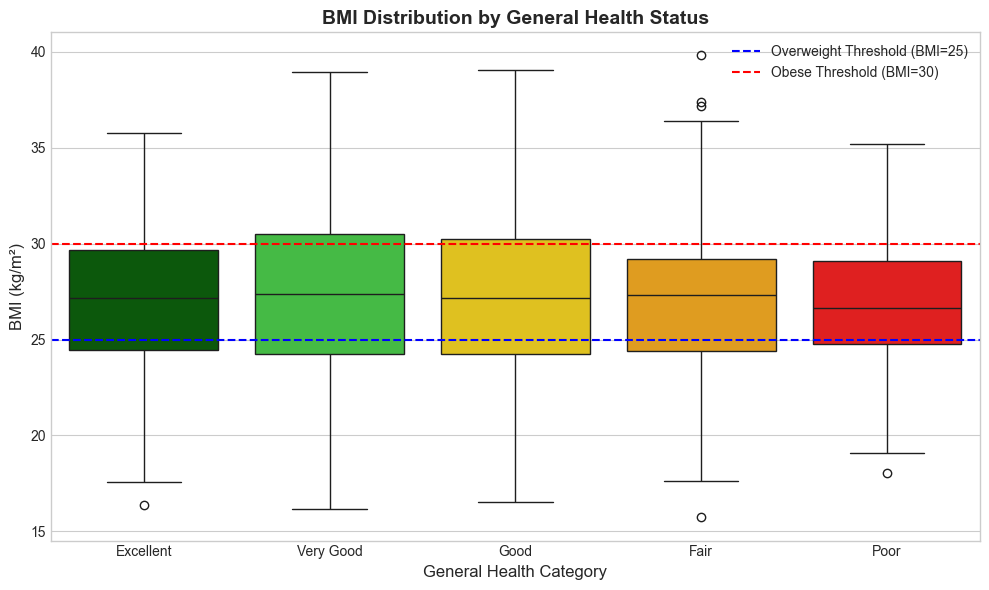


Mean BMI by General Health Category:
  Excellent: 26.98
  Very Good: 27.33
  Good: 27.31
  Fair: 27.14
  Poor: 26.83


In [14]:
# Chart 7: BMI vs. General Health (Boxplot)
fig, ax = plt.subplots(figsize=(10, 6))

# Order the health categories logically
health_order = ['excellent', 'very good', 'good', 'fair', 'poor']

# Create boxplot using seaborn
sns.boxplot(x='genhlth', y='bmi', data=df, order=health_order, 
            palette=['darkgreen', 'limegreen', 'gold', 'orange', 'red'], ax=ax)

# Add a horizontal line at BMI = 25 (overweight threshold)
ax.axhline(y=25, color='blue', linestyle='--', linewidth=1.5, label='Overweight Threshold (BMI=25)')
ax.axhline(y=30, color='red', linestyle='--', linewidth=1.5, label='Obese Threshold (BMI=30)')

# Labels and title
ax.set_xlabel('General Health Category', fontsize=12)
ax.set_ylabel('BMI (kg/m²)', fontsize=12)
ax.set_title('BMI Distribution by General Health Status', fontsize=14, fontweight='bold')
ax.set_xticklabels([cat.title() for cat in health_order])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print mean BMI by health category
print("\nMean BMI by General Health Category:")
bmi_by_health = df.groupby('genhlth')['bmi'].mean().reindex(health_order)
for cat, mean_bmi in bmi_by_health.items():
    print(f"  {cat.title()}: {mean_bmi:.2f}")

### Chart 8: BMI vs. Exercise Status
**Type:** Boxplot  
**Purpose:** Shows whether people who exercise tend to have lower BMI.

/var/folders/72/97y_q4kn2cng3wk1b79_ql8w0000gn/T/ipykernel_39554/391532931.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='exercise_label', y='bmi', data=df,


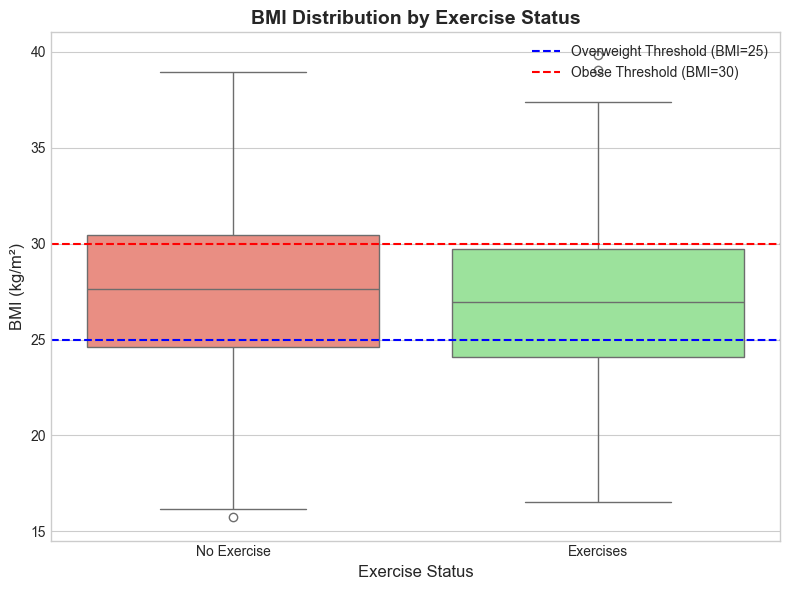


BMI Statistics by Exercise Status:
              mean  median   std
No Exercise  27.56   27.62  4.30
Exercises    27.01   26.95  4.07

Difference in mean BMI: 0.55 (Non-exercisers have higher BMI)


In [15]:
# Chart 8: BMI vs. Exercise Status (Boxplot)
fig, ax = plt.subplots(figsize=(8, 6))

# Create a mapping for better labels
df['exercise_label'] = df['exerany'].map({0: 'No Exercise', 1: 'Exercises'})

# Create boxplot using seaborn
sns.boxplot(x='exercise_label', y='bmi', data=df, 
            palette=['salmon', 'lightgreen'], ax=ax,
            order=['No Exercise', 'Exercises'])

# Add reference lines
ax.axhline(y=25, color='blue', linestyle='--', linewidth=1.5, label='Overweight Threshold (BMI=25)')
ax.axhline(y=30, color='red', linestyle='--', linewidth=1.5, label='Obese Threshold (BMI=30)')

# Labels and title
ax.set_xlabel('Exercise Status', fontsize=12)
ax.set_ylabel('BMI (kg/m²)', fontsize=12)
ax.set_title('BMI Distribution by Exercise Status', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print statistics
print("\nBMI Statistics by Exercise Status:")
bmi_by_exercise = df.groupby('exerany')['bmi'].agg(['mean', 'median', 'std'])
bmi_by_exercise.index = ['No Exercise', 'Exercises']
print(bmi_by_exercise.round(2))

# Calculate difference
no_ex_mean = df[df['exerany'] == 0]['bmi'].mean()
ex_mean = df[df['exerany'] == 1]['bmi'].mean()
print(f"\nDifference in mean BMI: {no_ex_mean - ex_mean:.2f} (Non-exercisers have higher BMI)")

### Chart 9: Correlation Heatmap
**Type:** Heatmap  
**Purpose:** Summarize relationships among all numeric variables (age, height, weight, BMI).

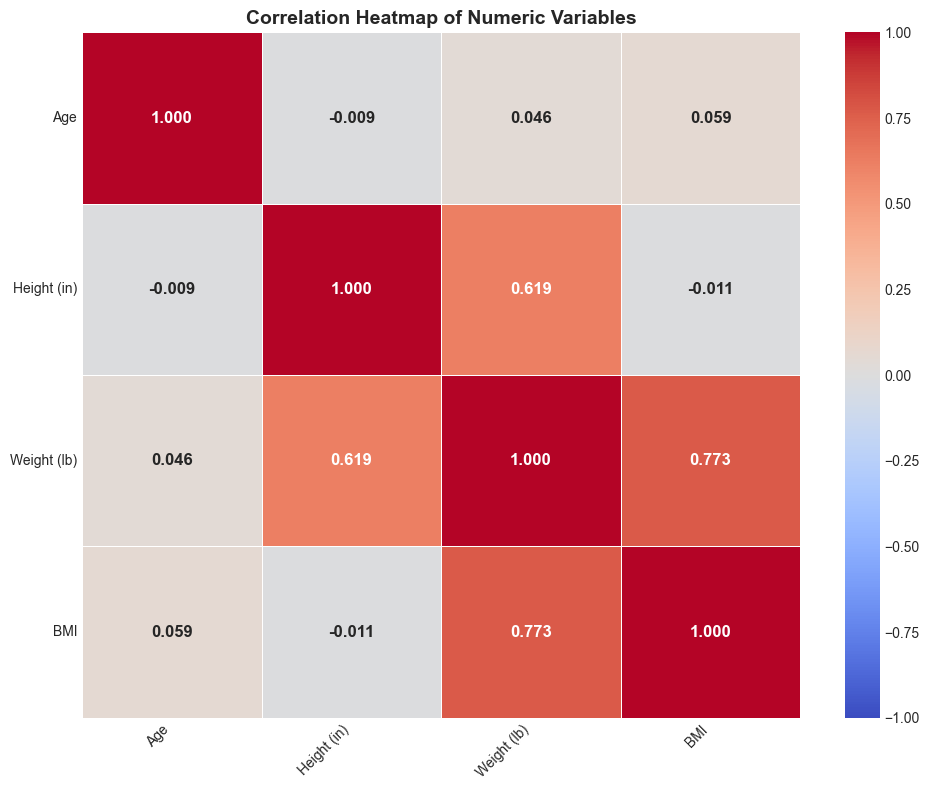


Correlation Interpretations:
Age & Height: -0.009 - Weak/negligible
Age & Weight: 0.046 - Weak
Age & BMI: 0.059 - Weak
Height & Weight: 0.619 - Moderate positive
Height & BMI: -0.011 - Weak/negligible
Weight & BMI: 0.773 - Strong positive


In [16]:
# Chart 9: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Select numeric columns for correlation
numeric_cols = ['age', 'height_in', 'weight_lb', 'bmi']
correlation_matrix = df[numeric_cols].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=0.5, ax=ax, 
            annot_kws={'size': 12, 'fontweight': 'bold'},
            vmin=-1, vmax=1)

# Labels and title
ax.set_title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Age', 'Height (in)', 'Weight (lb)', 'BMI'], rotation=45, ha='right')
ax.set_yticklabels(['Age', 'Height (in)', 'Weight (lb)', 'BMI'], rotation=0)

plt.tight_layout()
plt.show()

# Print correlation interpretations
print("\nCorrelation Interpretations:")
print("=" * 50)
print(f"Age & Height: {correlation_matrix.loc['age', 'height_in']:.3f} - Weak/negligible")
print(f"Age & Weight: {correlation_matrix.loc['age', 'weight_lb']:.3f} - Weak")
print(f"Age & BMI: {correlation_matrix.loc['age', 'bmi']:.3f} - Weak")
print(f"Height & Weight: {correlation_matrix.loc['height_in', 'weight_lb']:.3f} - Moderate positive")
print(f"Height & BMI: {correlation_matrix.loc['height_in', 'bmi']:.3f} - Weak/negligible")
print(f"Weight & BMI: {correlation_matrix.loc['weight_lb', 'bmi']:.3f} - Strong positive")

---

## Summary

This exploratory data analysis covered:

1. **Age Distribution** - Understanding the age demographics of the sample
2. **BMI Distribution** - Analyzing weight status categories in the population
3. **Height vs. Weight** - Visualizing the relationship and BMI patterns
4. **Exercise by Gender** - Comparing physical activity between genders
5. **Smoking by Gender** - Analyzing smoking patterns by gender
6. **General Health Distribution** - Self-reported health status
7. **BMI vs. Health** - Relationship between BMI and perceived health
8. **BMI vs. Exercise** - Impact of exercise on BMI
9. **Correlation Heatmap** - Relationships among numeric variables

---

# Part 2: Regression and Statistical Analysis

## Setup: Import Additional Libraries for Regression

In [17]:
# Import additional libraries for regression analysis
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import chi2_contingency, chisquare
import warnings
warnings.filterwarnings('ignore')

print("Regression libraries imported successfully!")

Regression libraries imported successfully!


In [18]:
# Prepare data for regression analysis
# Convert gender to dummy variable (M=1, F=0)
df['gender_dummy'] = (df['gender'] == 'M').astype(int)

# Convert genhlth to numeric scale
health_mapping = {
    'excellent': 5,
    'very good': 4,
    'good': 3,
    'fair': 2,
    'poor': 1
}
df['genhlth_numeric'] = df['genhlth'].map(health_mapping)

# Recreate BMI category if not exists
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(categorize_bmi)

# Display updated dataframe
print("Data prepared for regression analysis:")
print(f"Gender dummy (M=1, F=0): {df['gender_dummy'].value_counts().to_dict()}")
print(f"Health numeric mapping: {health_mapping}")
df[['gender', 'gender_dummy', 'genhlth', 'genhlth_numeric']].head(10)

Data prepared for regression analysis:
Gender dummy (M=1, F=0): {0: 559, 1: 441}
Health numeric mapping: {'excellent': 5, 'very good': 4, 'good': 3, 'fair': 2, 'poor': 1}


,gender,gender_dummy,genhlth,genhlth_numeric
0,M,1,excellent,5
1,M,1,fair,2
2,M,1,excellent,5
3,F,0,good,3
4,F,0,fair,2
5,F,0,excellent,5
6,F,0,very good,4
7,F,0,poor,1
8,M,1,fair,2
9,M,1,very good,4


---

## QUESTION 1: Multiple Regression Predicting BMI

**Model:** `bmi ~ age + gender + exerany + smoke100 + hlthplan`

**Purpose:** Determine which factors significantly predict BMI.

In [19]:
# QUESTION 1: Multiple Regression Predicting BMI
# Model: bmi ~ age + gender + exerany + smoke100 + hlthplan

# Fit the model using statsmodels formula API
model_q1 = smf.ols('bmi ~ age + gender_dummy + exerany + smoke100 + hlthplan', data=df).fit()

# Display regression summary
print("=" * 80)
print("QUESTION 1: Multiple Regression Predicting BMI")
print("=" * 80)
print(model_q1.summary())

QUESTION 1: Multiple Regression Predicting BMI
                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.167
Date:                Wed, 03 Dec 2025   Prob (F-statistic):             0.0556
Time:                        00:20:17   Log-Likelihood:                -2839.6
No. Observations:                1000   AIC:                             5691.
Df Residuals:                     994   BIC:                             5721.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
I

In [20]:
# Question 1: Interpretation of Results
print("\n" + "=" * 80)
print("INTERPRETATION OF QUESTION 1 RESULTS")
print("=" * 80)

# Extract significant predictors (p < 0.05)
print("\n📊 Model Performance:")
print(f"   R-squared: {model_q1.rsquared:.4f}")
print(f"   Adjusted R-squared: {model_q1.rsquared_adj:.4f}")
print(f"   F-statistic: {model_q1.fvalue:.4f}")
print(f"   F-test p-value: {model_q1.f_pvalue:.4e}")

print("\n📌 Coefficient Interpretation:")
for var in ['age', 'gender_dummy', 'exerany', 'smoke100', 'hlthplan']:
    coef = model_q1.params[var]
    pval = model_q1.pvalues[var]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"   {var}: coef = {coef:.4f}, p = {pval:.4f} {sig}")

print("\n📝 Significant Predictors (p < 0.05):")
significant = model_q1.pvalues[model_q1.pvalues < 0.05]
if len(significant) > 1:  # Excluding intercept
    for var in significant.index:
        if var != 'Intercept':
            coef = model_q1.params[var]
            if var == 'gender_dummy':
                print(f"   - Gender: Males have {abs(coef):.2f} {'higher' if coef > 0 else 'lower'} BMI than females")
            elif var == 'exerany':
                print(f"   - Exercise: People who exercise have {abs(coef):.2f} {'higher' if coef > 0 else 'lower'} BMI")
            elif var == 'smoke100':
                print(f"   - Smoking: Smokers have {abs(coef):.2f} {'higher' if coef > 0 else 'lower'} BMI")
            elif var == 'hlthplan':
                print(f"   - Health Plan: Those with health plan have {abs(coef):.2f} {'higher' if coef > 0 else 'lower'} BMI")
            elif var == 'age':
                print(f"   - Age: Each year increase in age is associated with {coef:.3f} change in BMI")
else:
    print("   No predictors are statistically significant at p < 0.05")


INTERPRETATION OF QUESTION 1 RESULTS

📊 Model Performance:
   R-squared: 0.0108
   Adjusted R-squared: 0.0058
   F-statistic: 2.1672
   F-test p-value: 5.5631e-02

📌 Coefficient Interpretation:
   age: coef = 0.0131, p = 0.0712 
   gender_dummy: coef = 0.0155, p = 0.9533 
   exerany: coef = -0.5524, p = 0.0431 *
   smoke100: coef = -0.4940, p = 0.0673 
   hlthplan: coef = -0.0496, p = 0.8938 

📝 Significant Predictors (p < 0.05):
   - Exercise: People who exercise have 0.55 lower BMI


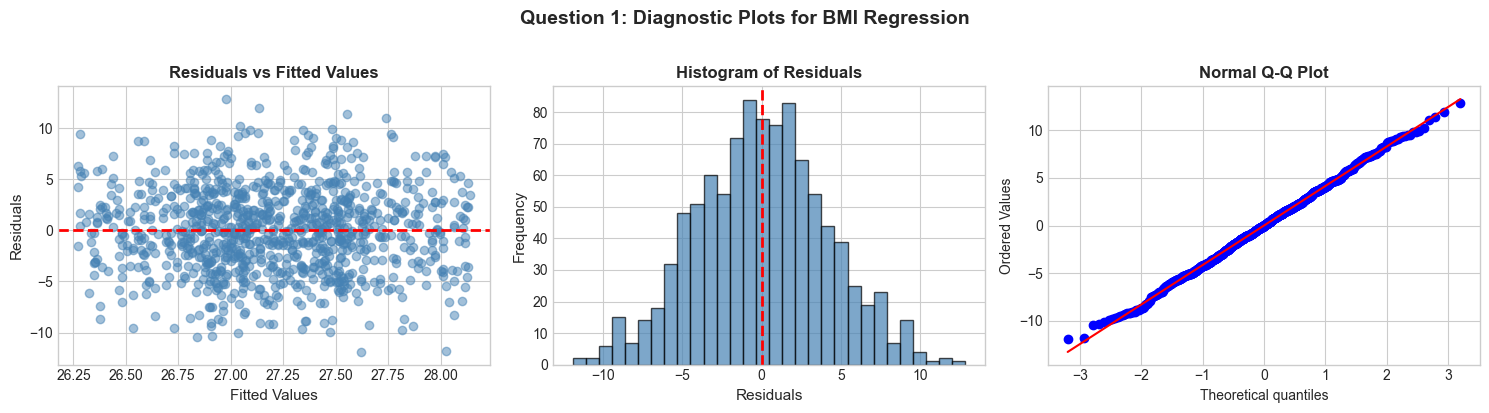

In [21]:
# Question 1: Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get fitted values and residuals
fitted_q1 = model_q1.fittedvalues
residuals_q1 = model_q1.resid

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_q1, residuals_q1, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')

# Plot 2: Histogram of Residuals
axes[1].hist(residuals_q1, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Histogram of Residuals', fontsize=12, fontweight='bold')

# Plot 3: Q-Q Plot
stats.probplot(residuals_q1, dist="norm", plot=axes[2])
axes[2].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')

plt.suptitle('Question 1: Diagnostic Plots for BMI Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## QUESTION 2: Regression Predicting Self-Rated Health

**Model:** `genhlth_numeric ~ age + bmi + exerany + smoke100 + hlthplan`

**Health Scale:** excellent=5, very good=4, good=3, fair=2, poor=1

**Purpose:** Determine which factors predict self-reported health status.

In [22]:
# QUESTION 2: Regression Predicting Self-Rated Health
# Model: genhlth_numeric ~ age + bmi + exerany + smoke100 + hlthplan

model_q2 = smf.ols('genhlth_numeric ~ age + bmi + exerany + smoke100 + hlthplan', data=df).fit()

print("=" * 80)
print("QUESTION 2: Regression Predicting Self-Rated Health")
print("=" * 80)
print(model_q2.summary())

QUESTION 2: Regression Predicting Self-Rated Health
                            OLS Regression Results                            
Dep. Variable:        genhlth_numeric   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7160
Date:                Wed, 03 Dec 2025   Prob (F-statistic):              0.612
Time:                        00:20:17   Log-Likelihood:                -1517.2
No. Observations:                1000   AIC:                             3046.
Df Residuals:                     994   BIC:                             3076.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


In [23]:
# Question 2: Interpretation of Results
print("\n" + "=" * 80)
print("INTERPRETATION OF QUESTION 2 RESULTS")
print("=" * 80)

print("\n📊 Model Performance:")
print(f"   R-squared: {model_q2.rsquared:.4f}")
print(f"   Adjusted R-squared: {model_q2.rsquared_adj:.4f}")
print(f"   F-statistic: {model_q2.fvalue:.4f}")
print(f"   F-test p-value: {model_q2.f_pvalue:.4e}")

print("\n📌 Coefficient Interpretation:")
for var in ['age', 'bmi', 'exerany', 'smoke100', 'hlthplan']:
    coef = model_q2.params[var]
    pval = model_q2.pvalues[var]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"   {var}: coef = {coef:.4f}, p = {pval:.4f} {sig}")

print("\n📝 Significant Predictors (p < 0.05):")
for var in ['age', 'bmi', 'exerany', 'smoke100', 'hlthplan']:
    pval = model_q2.pvalues[var]
    coef = model_q2.params[var]
    if pval < 0.05:
        direction = "higher" if coef > 0 else "lower"
        print(f"   - {var}: Associated with {direction} self-rated health (coef = {coef:.4f})")


INTERPRETATION OF QUESTION 2 RESULTS

📊 Model Performance:
   R-squared: 0.0036
   Adjusted R-squared: -0.0014
   F-statistic: 0.7160
   F-test p-value: 6.1150e-01

📌 Coefficient Interpretation:
   age: coef = -0.0027, p = 0.1681 
   bmi: coef = 0.0021, p = 0.8026 
   exerany: coef = 0.0476, p = 0.5133 
   smoke100: coef = 0.0793, p = 0.2707 
   hlthplan: coef = -0.0017, p = 0.9864 

📝 Significant Predictors (p < 0.05):


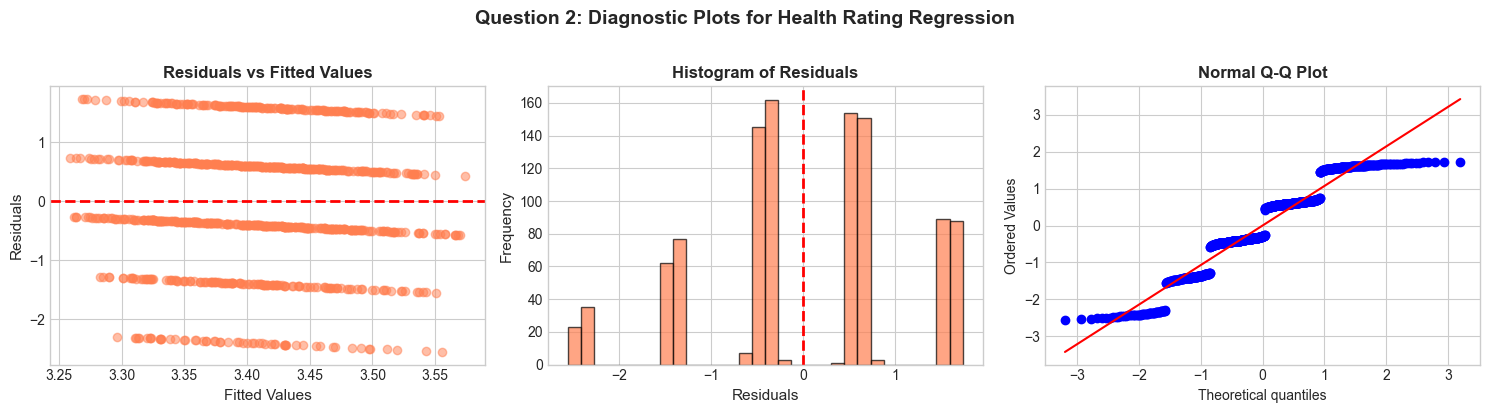

In [24]:
# Question 2: Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fitted_q2 = model_q2.fittedvalues
residuals_q2 = model_q2.resid

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_q2, residuals_q2, alpha=0.5, color='coral')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')

# Plot 2: Histogram of Residuals
axes[1].hist(residuals_q2, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Histogram of Residuals', fontsize=12, fontweight='bold')

# Plot 3: Q-Q Plot
stats.probplot(residuals_q2, dist="norm", plot=axes[2])
axes[2].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')

plt.suptitle('Question 2: Diagnostic Plots for Health Rating Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## QUESTION 3: Model Comparison (Exercise Effect on Health)

**Model A (Without Exercise):** `genhlth_numeric ~ age + bmi + smoke100 + hlthplan`

**Model B (With Exercise):** `genhlth_numeric ~ age + bmi + smoke100 + hlthplan + exerany`

**Purpose:** Determine if adding exercise improves the model's predictive power.

In [25]:
# QUESTION 3: Model Comparison (Exercise Effect on Health)

# Model A: Without Exercise
model_A = smf.ols('genhlth_numeric ~ age + bmi + smoke100 + hlthplan', data=df).fit()

# Model B: With Exercise
model_B = smf.ols('genhlth_numeric ~ age + bmi + smoke100 + hlthplan + exerany', data=df).fit()

print("=" * 80)
print("QUESTION 3: Model Comparison (Exercise Effect on Health)")
print("=" * 80)

print("\n" + "-" * 40)
print("MODEL A: Without Exercise")
print("-" * 40)
print(model_A.summary())

print("\n" + "-" * 40)
print("MODEL B: With Exercise")
print("-" * 40)
print(model_B.summary())

QUESTION 3: Model Comparison (Exercise Effect on Health)

----------------------------------------
MODEL A: Without Exercise
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:        genhlth_numeric   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7885
Date:                Wed, 03 Dec 2025   Prob (F-statistic):              0.533
Time:                        00:20:17   Log-Likelihood:                -1517.4
No. Observations:                1000   AIC:                             3045.
Df Residuals:                     995   BIC:                             3069.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t 

In [26]:
# Question 3: Side-by-Side Comparison
print("\n" + "=" * 80)
print("SIDE-BY-SIDE MODEL COMPARISON")
print("=" * 80)

# Create comparison table
comparison_data = {
    'Metric': ['R-squared', 'Adjusted R-squared', 'AIC', 'BIC', 'F-statistic', 'F-test p-value'],
    'Model A (No Exercise)': [
        f"{model_A.rsquared:.4f}",
        f"{model_A.rsquared_adj:.4f}",
        f"{model_A.aic:.2f}",
        f"{model_A.bic:.2f}",
        f"{model_A.fvalue:.4f}",
        f"{model_A.f_pvalue:.4e}"
    ],
    'Model B (With Exercise)': [
        f"{model_B.rsquared:.4f}",
        f"{model_B.rsquared_adj:.4f}",
        f"{model_B.aic:.2f}",
        f"{model_B.bic:.2f}",
        f"{model_B.fvalue:.4f}",
        f"{model_B.f_pvalue:.4e}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n📊 Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Coefficient comparison
print("\n📌 Coefficient Comparison:")
print(f"{'Variable':<15} {'Model A':<15} {'Model B':<15}")
print("-" * 45)
for var in ['age', 'bmi', 'smoke100', 'hlthplan']:
    coef_A = model_A.params[var]
    coef_B = model_B.params[var]
    print(f"{var:<15} {coef_A:<15.4f} {coef_B:<15.4f}")
print(f"{'exerany':<15} {'N/A':<15} {model_B.params['exerany']:<15.4f}")

# Conclusion
print("\n" + "=" * 80)
print("📝 CONCLUSION: Does adding exercise improve prediction?")
print("=" * 80)
r2_improvement = model_B.rsquared - model_A.rsquared
adj_r2_improvement = model_B.rsquared_adj - model_A.rsquared_adj
exerany_pval = model_B.pvalues['exerany']

print(f"\n   R² improvement: {r2_improvement:.4f} ({r2_improvement*100:.2f}%)")
print(f"   Adjusted R² improvement: {adj_r2_improvement:.4f}")
print(f"   Exercise coefficient p-value: {exerany_pval:.4f}")

if exerany_pval < 0.05:
    print(f"\n   ✅ YES - Adding exercise significantly improves the model.")
    print(f"      Exercise is a significant predictor (p = {exerany_pval:.4f} < 0.05)")
else:
    print(f"\n   ❌ NO - Adding exercise does NOT significantly improve the model.")
    print(f"      Exercise is not a significant predictor (p = {exerany_pval:.4f} ≥ 0.05)")


SIDE-BY-SIDE MODEL COMPARISON

📊 Model Performance Comparison:
            Metric Model A (No Exercise) Model B (With Exercise)
         R-squared                0.0032                  0.0036
Adjusted R-squared               -0.0008                 -0.0014
               AIC               3044.82                 3046.39
               BIC               3069.36                 3075.84
       F-statistic                0.7885                  0.7160
    F-test p-value            5.3270e-01              6.1150e-01

📌 Coefficient Comparison:
Variable        Model A         Model B        
---------------------------------------------
age             -0.0027         -0.0027        
bmi             0.0018          0.0021         
smoke100        0.0779          0.0793         
hlthplan        0.0005          -0.0017        
exerany         N/A             0.0476         

📝 CONCLUSION: Does adding exercise improve prediction?

   R² improvement: 0.0004 (0.04%)
   Adjusted R² improvement: -

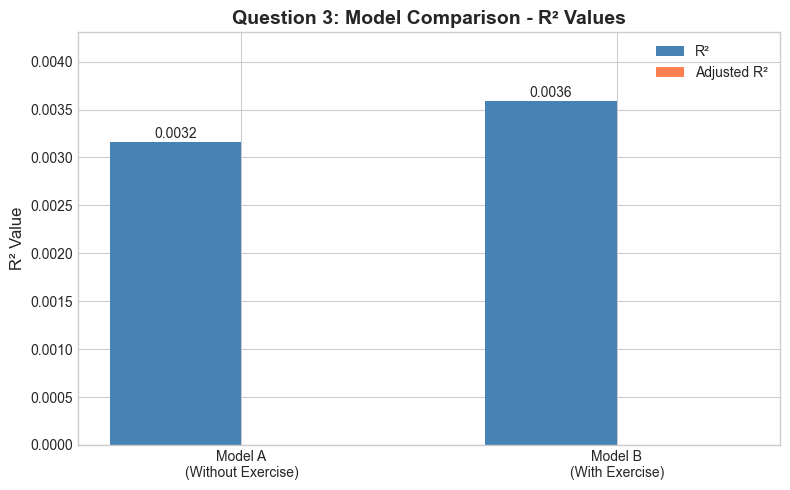

In [27]:
# Question 3: R² Comparison Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Model A\n(Without Exercise)', 'Model B\n(With Exercise)']
r2_values = [model_A.rsquared, model_B.rsquared]
adj_r2_values = [model_A.rsquared_adj, model_B.rsquared_adj]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, r2_values, width, label='R²', color='steelblue')
bars2 = ax.bar(x + width/2, adj_r2_values, width, label='Adjusted R²', color='coral')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

ax.set_ylabel('R² Value', fontsize=12)
ax.set_title('Question 3: Model Comparison - R² Values', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(r2_values) * 1.2)

plt.tight_layout()
plt.show()

---

## QUESTION 4: Categorical Analysis (Exercise × Health Plan)

**Test:** Chi-Square Test of Independence

**Purpose:** Determine if there is a relationship between exercise status and having a health plan.

In [28]:
# QUESTION 4: Chi-Square Test of Independence (Exercise × Health Plan)

print("=" * 80)
print("QUESTION 4: Chi-Square Test of Independence (Exercise × Health Plan)")
print("=" * 80)

# Create contingency table
contingency_table = pd.crosstab(df['exerany'], df['hlthplan'], 
                                 rownames=['Exercise (0=No, 1=Yes)'], 
                                 colnames=['Health Plan (0=No, 1=Yes)'])

print("\n📊 Observed Contingency Table:")
print(contingency_table)

# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n📌 Chi-Square Test Results:")
print(f"   Chi-square statistic (χ²): {chi2:.4f}")
print(f"   Degrees of freedom: {dof}")
print(f"   p-value: {p_value:.4f}")

print("\n📋 Expected Frequencies (if independent):")
expected_df = pd.DataFrame(expected, 
                           index=['No Exercise', 'Exercises'],
                           columns=['No Health Plan', 'Has Health Plan'])
print(expected_df.round(2))

# Interpretation
print("\n" + "=" * 80)
print("📝 INTERPRETATION:")
print("=" * 80)
if p_value < 0.05:
    print(f"   ✅ SIGNIFICANT (p = {p_value:.4f} < 0.05)")
    print("   There IS a significant relationship between exercise and health plan status.")
else:
    print(f"   ❌ NOT SIGNIFICANT (p = {p_value:.4f} ≥ 0.05)")
    print("   There is NO significant relationship between exercise and health plan status.")

QUESTION 4: Chi-Square Test of Independence (Exercise × Health Plan)

📊 Observed Contingency Table:
Health Plan (0=No, 1=Yes)   0    1
Exercise (0=No, 1=Yes)            
0                          60  307
1                          87  546

📌 Chi-Square Test Results:
   Chi-square statistic (χ²): 1.0578
   Degrees of freedom: 1
   p-value: 0.3037

📋 Expected Frequencies (if independent):
             No Health Plan  Has Health Plan
No Exercise           53.95           313.05
Exercises             93.05           539.95

📝 INTERPRETATION:
   ❌ NOT SIGNIFICANT (p = 0.3037 ≥ 0.05)
   There is NO significant relationship between exercise and health plan status.


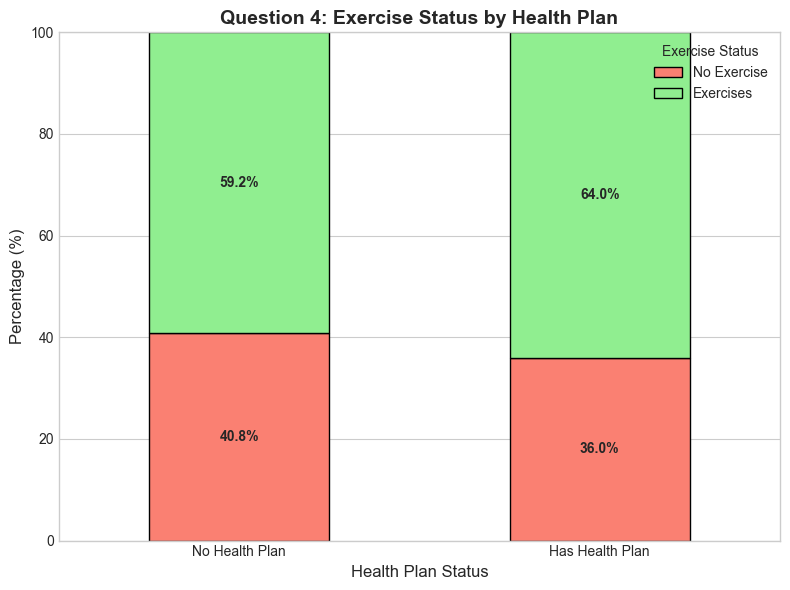

In [29]:
# Question 4: Stacked Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate percentages
exercise_by_hlthplan = pd.crosstab(df['hlthplan'], df['exerany'], normalize='index') * 100

# Plot stacked bar chart
exercise_by_hlthplan.plot(kind='bar', stacked=True, ax=ax, 
                          color=['salmon', 'lightgreen'], edgecolor='black')

ax.set_xlabel('Health Plan Status', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Question 4: Exercise Status by Health Plan', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Health Plan', 'Has Health Plan'], rotation=0)
ax.legend(['No Exercise', 'Exercises'], title='Exercise Status', loc='upper right')
ax.set_ylim(0, 100)

# Add percentage labels
for i, (idx, row) in enumerate(exercise_by_hlthplan.iterrows()):
    cumsum = 0
    for j, val in enumerate(row):
        ax.text(i, cumsum + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold')
        cumsum += val

plt.tight_layout()
plt.show()

---

## QUESTION 5: Goodness-of-Fit Test (General Health vs National Distribution)

**Test:** Chi-Square Goodness-of-Fit Test

**Purpose:** Determine if our sample's health distribution matches the national distribution.

**Note:** You may need to adjust the expected percentages based on your assignment's national distribution.

In [30]:
# QUESTION 5: Goodness-of-Fit Test (General Health vs National Distribution)

print("=" * 80)
print("QUESTION 5: Goodness-of-Fit Test (General Health vs National Distribution)")
print("=" * 80)

# Get observed frequencies
health_order = ['excellent', 'very good', 'good', 'fair', 'poor']
observed_counts = df['genhlth'].value_counts().reindex(health_order)

# National expected percentages (ADJUST THESE BASED ON YOUR ASSIGNMENT)
# These are example values - replace with the actual national percentages from your assignment
national_percentages = {
    'excellent': 0.20,   # 20% - adjust as needed
    'very good': 0.35,   # 35% - adjust as needed
    'good': 0.30,        # 30% - adjust as needed
    'fair': 0.10,        # 10% - adjust as needed
    'poor': 0.05         # 5% - adjust as needed
}

# Calculate expected frequencies
n = len(df)
expected_counts = [n * national_percentages[cat] for cat in health_order]

print("\n📊 Observed vs Expected Frequencies:")
comparison_data = {
    'Category': health_order,
    'Observed': observed_counts.values,
    'Expected': expected_counts,
    'Observed %': (observed_counts.values / n * 100).round(1),
    'Expected %': [p * 100 for p in national_percentages.values()]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Perform Chi-Square Goodness-of-Fit test
chi2_stat, p_value = chisquare(observed_counts.values, f_exp=expected_counts)
dof = len(health_order) - 1

print("\n📌 Chi-Square Goodness-of-Fit Test Results:")
print(f"   Chi-square statistic (χ²): {chi2_stat:.4f}")
print(f"   Degrees of freedom: {dof}")
print(f"   p-value: {p_value:.4f}")

# Interpretation
print("\n" + "=" * 80)
print("📝 INTERPRETATION:")
print("=" * 80)
if p_value < 0.05:
    print(f"   ✅ SIGNIFICANT (p = {p_value:.4f} < 0.05)")
    print("   Our sample's health distribution is SIGNIFICANTLY DIFFERENT from the national distribution.")
else:
    print(f"   ❌ NOT SIGNIFICANT (p = {p_value:.4f} ≥ 0.05)")
    print("   Our sample's health distribution is NOT significantly different from the national distribution.")

QUESTION 5: Goodness-of-Fit Test (General Health vs National Distribution)

📊 Observed vs Expected Frequencies:
 Category  Observed  Expected  Observed %  Expected %
excellent       177     200.0        17.7        20.0
very good       309     350.0        30.9        35.0
     good       317     300.0        31.7        30.0
     fair       139     100.0        13.9        10.0
     poor        58      50.0         5.8         5.0

📌 Chi-Square Goodness-of-Fit Test Results:
   Chi-square statistic (χ²): 24.9012
   Degrees of freedom: 4
   p-value: 0.0001

📝 INTERPRETATION:
   ✅ SIGNIFICANT (p = 0.0001 < 0.05)
   Our sample's health distribution is SIGNIFICANTLY DIFFERENT from the national distribution.


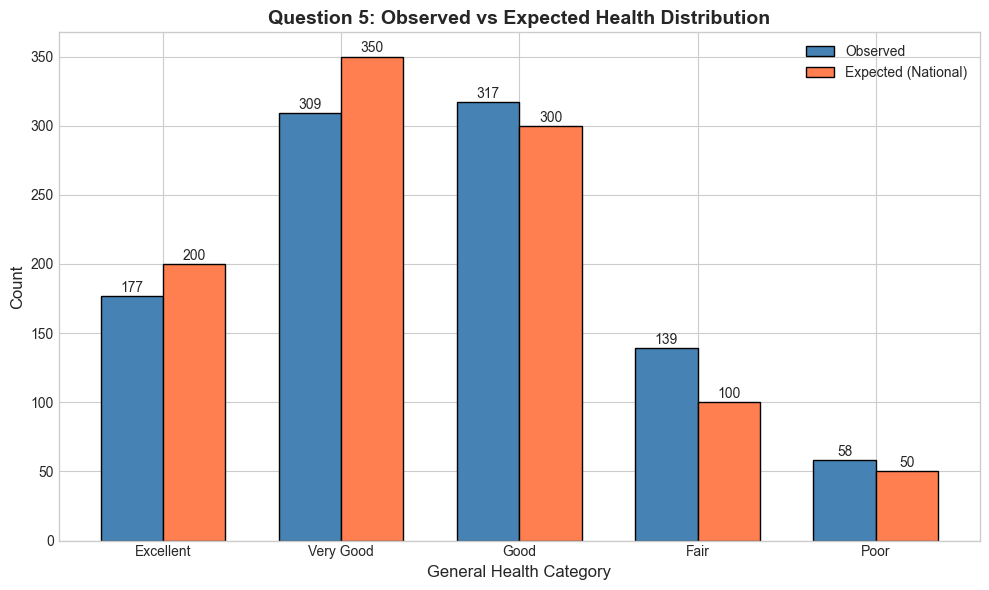

In [31]:
# Question 5: Observed vs Expected Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(health_order))
width = 0.35

bars1 = ax.bar(x - width/2, observed_counts.values, width, label='Observed', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, expected_counts, width, label='Expected (National)', color='coral', edgecolor='black')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

ax.set_xlabel('General Health Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Question 5: Observed vs Expected Health Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([cat.title() for cat in health_order])
ax.legend()

plt.tight_layout()
plt.show()

---

## QUESTION 6: Simple Regression (Height Predicting Weight)

**Model:** `weight_lb ~ height_in`

**Purpose:** Determine if height is a significant predictor of weight.

In [32]:
# QUESTION 6: Simple Regression (Height Predicting Weight)

model_q6 = smf.ols('weight_lb ~ height_in', data=df).fit()

print("=" * 80)
print("QUESTION 6: Simple Regression (Height Predicting Weight)")
print("=" * 80)
print(model_q6.summary())

QUESTION 6: Simple Regression (Height Predicting Weight)
                            OLS Regression Results                            
Dep. Variable:              weight_lb   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     619.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):          8.47e-107
Time:                        00:20:17   Log-Likelihood:                -4690.9
No. Observations:                1000   AIC:                             9386.
Df Residuals:                     998   BIC:                             9396.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [33]:
# Question 6: Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION OF QUESTION 6 RESULTS")
print("=" * 80)

slope = model_q6.params['height_in']
intercept = model_q6.params['Intercept']
r_squared = model_q6.rsquared
p_value = model_q6.pvalues['height_in']

print("\n📊 Model Performance:")
print(f"   R-squared: {r_squared:.4f}")
print(f"   Adjusted R-squared: {model_q6.rsquared_adj:.4f}")

print("\n📌 Regression Equation:")
print(f"   Weight (lbs) = {intercept:.2f} + {slope:.2f} × Height (inches)")

print("\n📝 Slope Interpretation:")
print(f"   For every 1-inch increase in height, weight increases by {slope:.2f} pounds on average.")
print(f"   p-value = {p_value:.4e}")

if p_value < 0.05:
    print(f"\n   ✅ Height is a SIGNIFICANT predictor of weight (p < 0.05)")
else:
    print(f"\n   ❌ Height is NOT a significant predictor of weight (p ≥ 0.05)")
    
print(f"\n   R² = {r_squared:.4f} means height explains {r_squared*100:.1f}% of the variation in weight.")


INTERPRETATION OF QUESTION 6 RESULTS

📊 Model Performance:
   R-squared: 0.3831
   Adjusted R-squared: 0.3825

📌 Regression Equation:
   Weight (lbs) = -161.88 + 5.02 × Height (inches)

📝 Slope Interpretation:
   For every 1-inch increase in height, weight increases by 5.02 pounds on average.
   p-value = 8.4731e-107

   ✅ Height is a SIGNIFICANT predictor of weight (p < 0.05)

   R² = 0.3831 means height explains 38.3% of the variation in weight.


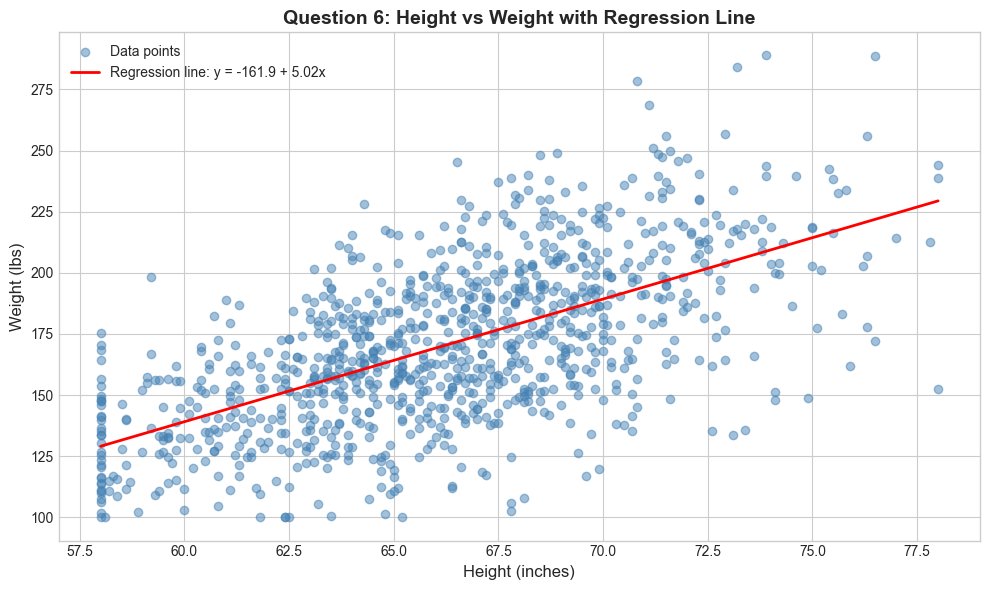

In [34]:
# Question 6: Scatterplot with Regression Line
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(df['height_in'], df['weight_lb'], alpha=0.5, color='steelblue', label='Data points')

# Regression line
x_line = np.linspace(df['height_in'].min(), df['height_in'].max(), 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label=f'Regression line: y = {intercept:.1f} + {slope:.2f}x')

ax.set_xlabel('Height (inches)', fontsize=12)
ax.set_ylabel('Weight (lbs)', fontsize=12)
ax.set_title('Question 6: Height vs Weight with Regression Line', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

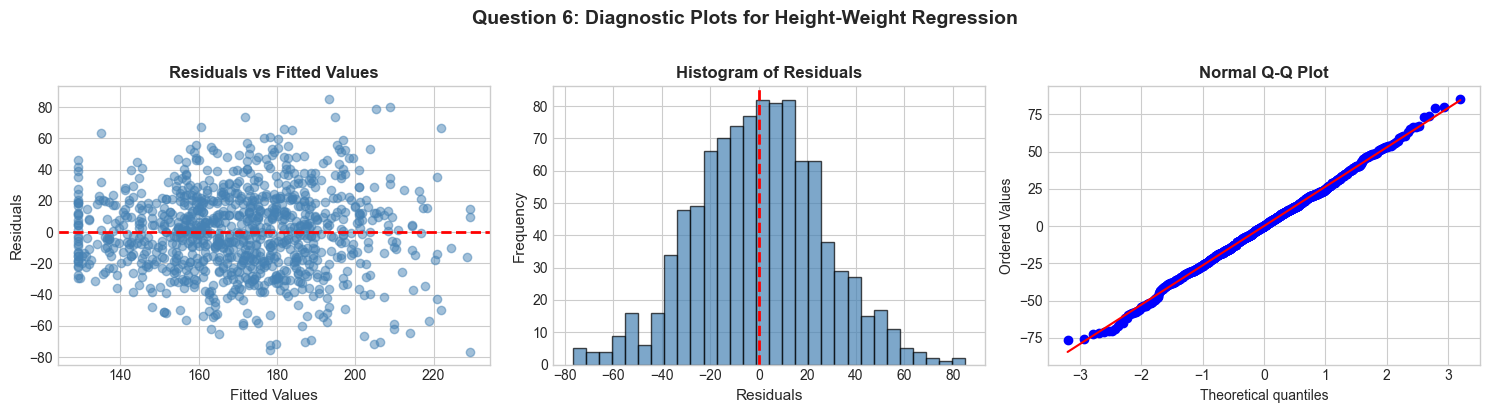

In [35]:
# Question 6: Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fitted_q6 = model_q6.fittedvalues
residuals_q6 = model_q6.resid

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_q6, residuals_q6, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')

# Plot 2: Histogram of Residuals
axes[1].hist(residuals_q6, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Histogram of Residuals', fontsize=12, fontweight='bold')

# Plot 3: Q-Q Plot
stats.probplot(residuals_q6, dist="norm", plot=axes[2])
axes[2].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')

plt.suptitle('Question 6: Diagnostic Plots for Height-Weight Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## QUESTION 7: Your Own Research Question

**Research Question:** Does exercise predict BMI when controlling for age and smoking status?

**Model:** `bmi ~ exerany + age + smoke100`

**Purpose:** Investigate whether physical activity significantly predicts BMI after accounting for age and smoking.

In [36]:
# QUESTION 7: Exercise Predicting BMI (controlling for age + smoking)

model_q7 = smf.ols('bmi ~ exerany + age + smoke100', data=df).fit()

print("=" * 80)
print("QUESTION 7: Exercise Predicting BMI (controlling for age + smoking)")
print("=" * 80)
print(model_q7.summary())

QUESTION 7: Exercise Predicting BMI (controlling for age + smoking)
                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.612
Date:                Wed, 03 Dec 2025   Prob (F-statistic):             0.0130
Time:                        00:20:17   Log-Likelihood:                -2839.6
No. Observations:                1000   AIC:                             5687.
Df Residuals:                     996   BIC:                             5707.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [37]:
# Question 7: Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION OF QUESTION 7 RESULTS")
print("=" * 80)

print("\n📊 Model Performance:")
print(f"   R-squared: {model_q7.rsquared:.4f}")
print(f"   Adjusted R-squared: {model_q7.rsquared_adj:.4f}")
print(f"   F-statistic: {model_q7.fvalue:.4f}")
print(f"   F-test p-value: {model_q7.f_pvalue:.4e}")

print("\n📌 Coefficient Summary:")
for var in ['exerany', 'age', 'smoke100']:
    coef = model_q7.params[var]
    pval = model_q7.pvalues[var]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"   {var}: coef = {coef:.4f}, p = {pval:.4f} {sig}")

# Main research question answer
exerany_coef = model_q7.params['exerany']
exerany_pval = model_q7.pvalues['exerany']

print("\n" + "=" * 80)
print("📝 ANSWER TO RESEARCH QUESTION:")
print("   Does exercise significantly predict BMI (controlling for age and smoking)?")
print("=" * 80)

if exerany_pval < 0.05:
    print(f"\n   ✅ YES - Exercise significantly predicts BMI (p = {exerany_pval:.4f})")
    direction = "lower" if exerany_coef < 0 else "higher"
    print(f"   People who exercise have {abs(exerany_coef):.2f} {direction} BMI on average,")
    print(f"   after controlling for age and smoking status.")
else:
    print(f"\n   ❌ NO - Exercise does NOT significantly predict BMI (p = {exerany_pval:.4f})")
    print(f"   After controlling for age and smoking, exercise is not a significant predictor of BMI.")


INTERPRETATION OF QUESTION 7 RESULTS

📊 Model Performance:
   R-squared: 0.0108
   Adjusted R-squared: 0.0078
   F-statistic: 3.6119
   F-test p-value: 1.2961e-02

📌 Coefficient Summary:
   exerany: coef = -0.5538, p = 0.0423 *
   age: coef = 0.0131, p = 0.0704 
   smoke100: coef = -0.4932, p = 0.0674 

📝 ANSWER TO RESEARCH QUESTION:
   Does exercise significantly predict BMI (controlling for age and smoking)?

   ✅ YES - Exercise significantly predicts BMI (p = 0.0423)
   People who exercise have 0.55 lower BMI on average,
   after controlling for age and smoking status.


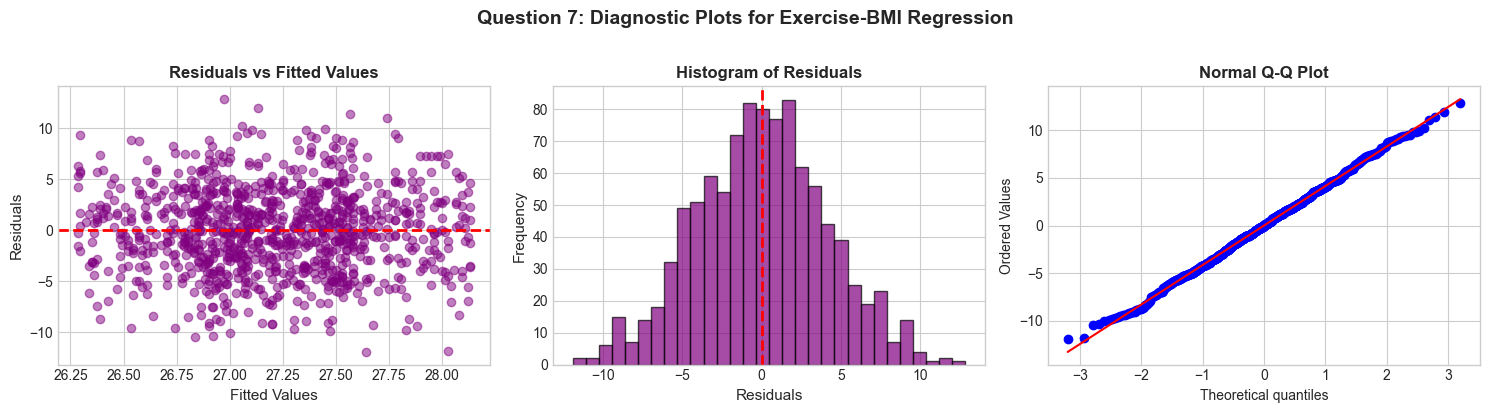

In [38]:
# Question 7: Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fitted_q7 = model_q7.fittedvalues
residuals_q7 = model_q7.resid

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_q7, residuals_q7, alpha=0.5, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')

# Plot 2: Histogram of Residuals
axes[1].hist(residuals_q7, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Histogram of Residuals', fontsize=12, fontweight='bold')

# Plot 3: Q-Q Plot
stats.probplot(residuals_q7, dist="norm", plot=axes[2])
axes[2].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')

plt.suptitle('Question 7: Diagnostic Plots for Exercise-BMI Regression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Summary of All Regression Analyses

| Question | Model Type | Dependent Variable | Key Finding |
|----------|------------|-------------------|-------------|
| Q1 | Multiple Regression | BMI | Predictors: age, gender, exercise, smoking, health plan |
| Q2 | Multiple Regression | Self-Rated Health | Predictors: age, BMI, exercise, smoking, health plan |
| Q3 | Model Comparison | Self-Rated Health | Compare models with/without exercise |
| Q4 | Chi-Square Independence | Exercise × Health Plan | Test association between categorical variables |
| Q5 | Chi-Square Goodness-of-Fit | General Health | Compare sample to national distribution |
| Q6 | Simple Regression | Weight | Height as predictor |
| Q7 | Multiple Regression | BMI | Exercise effect controlling for age and smoking |